# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

----------------------------------------
- Nama     : Zean Ananda Pratama
- Email    : apc179d6y0241@student.devacademy.id
- Dataset  : Crop Recommendation Dataset
- Sumber   : https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset

Deskripsi:
Dataset ini berisi data parameter tanah dan cuaca yang digunakan
untuk merekomendasikan jenis tanaman yang paling cocok ditanam.
Dataset memiliki 2200 baris dan 8 kolom:
  - N        : kandungan Nitrogen dalam tanah
  - P        : kandungan Fosfor dalam tanah
  - K        : kandungan Kalium dalam tanah
  - temperature : suhu udara (°C)
  - humidity : kelembaban udara (%)
  - ph       : tingkat keasaman tanah
  - rainfall : curah hujan (mm)
  - label    : jenis tanaman yang direkomendasikan (target)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
import warnings
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [35]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Membangun Sistem ML/Eksperimen_SML_Zean Ananda Pratama/crop_recommendation.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [36]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [38]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [39]:
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [40]:
df.duplicated().sum()

np.int64(0)

/tmp/ipykernel_6855/442782097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_counts.index, y=crop_counts.values, palette='viridis')


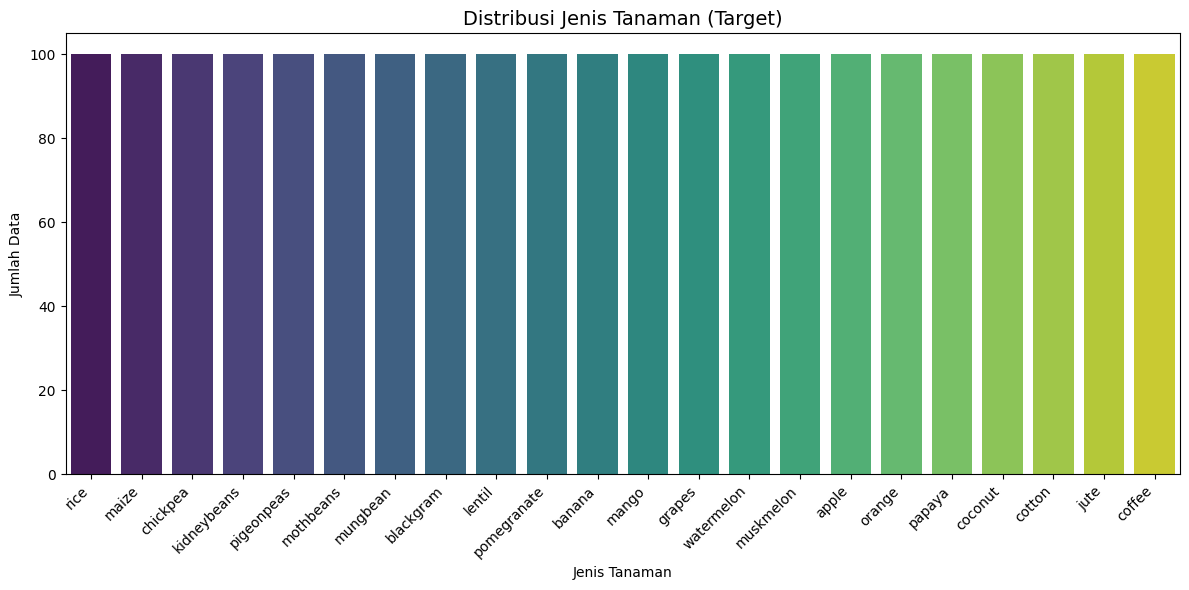

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [41]:
plt.figure(figsize=(12, 6))
crop_counts = df['label'].value_counts()
sns.barplot(x=crop_counts.index, y=crop_counts.values, palette='viridis')
plt.title('Distribusi Jenis Tanaman (Target)', fontsize=14)
plt.xlabel('Jenis Tanaman')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(crop_counts)

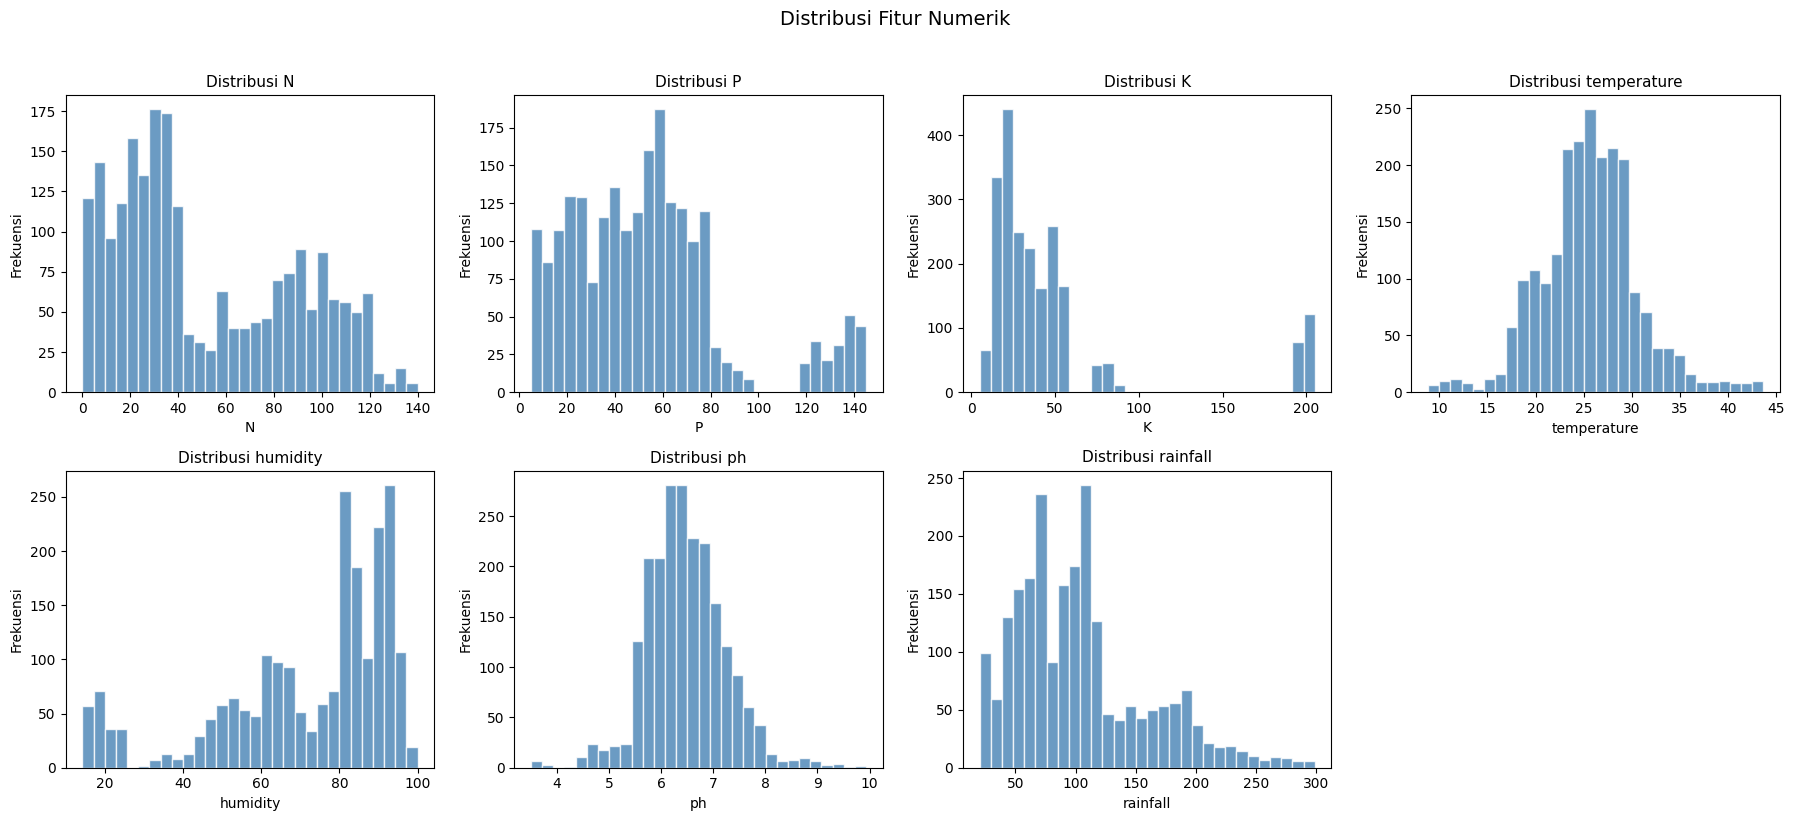

In [42]:
numerical_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

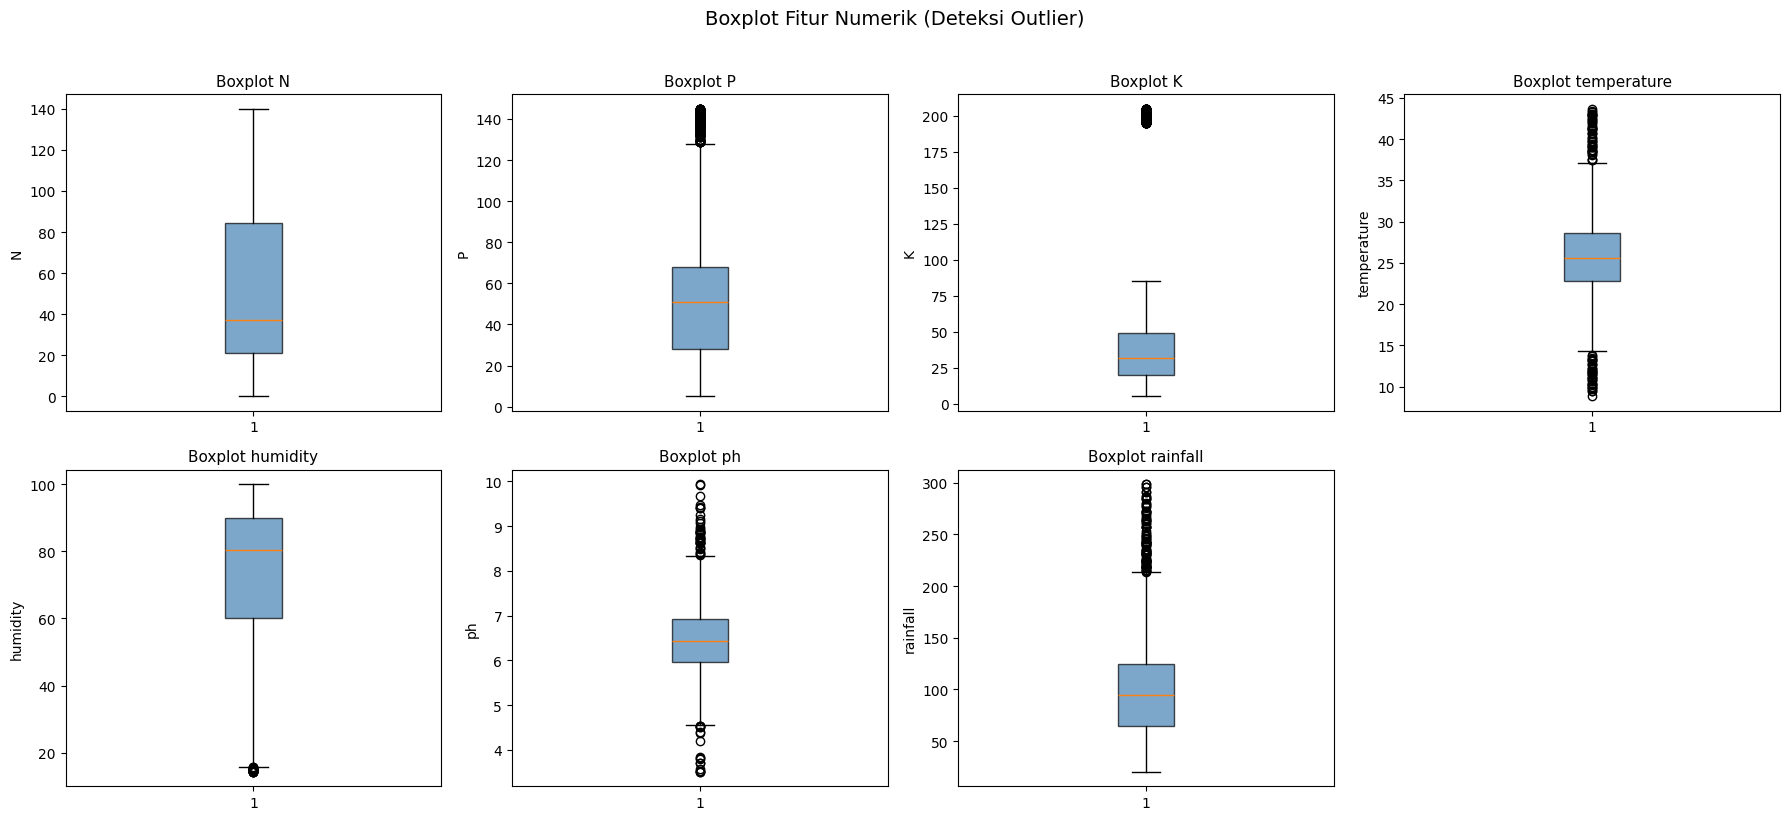

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(f'Boxplot {col}', fontsize=11)
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)
plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

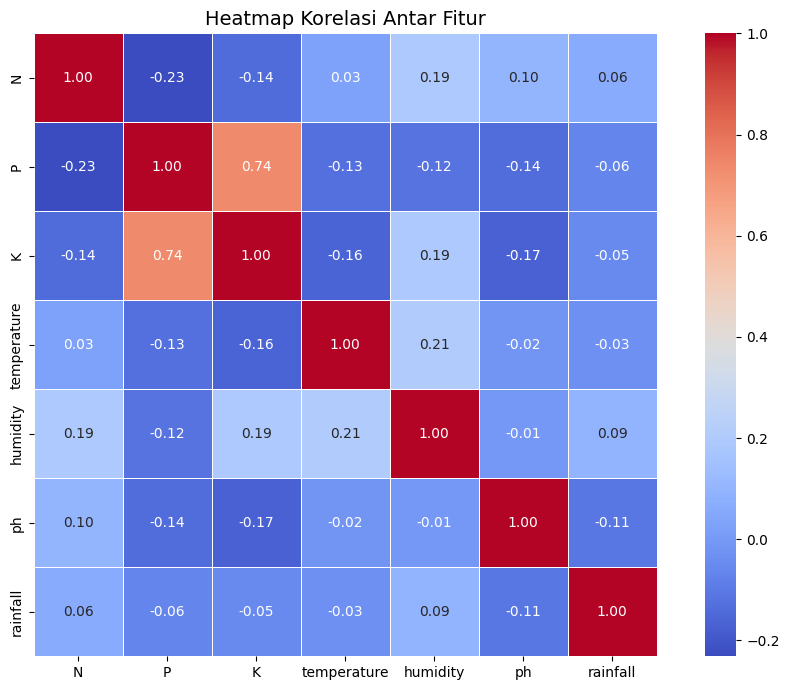

In [44]:
plt.figure(figsize=(10, 7))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

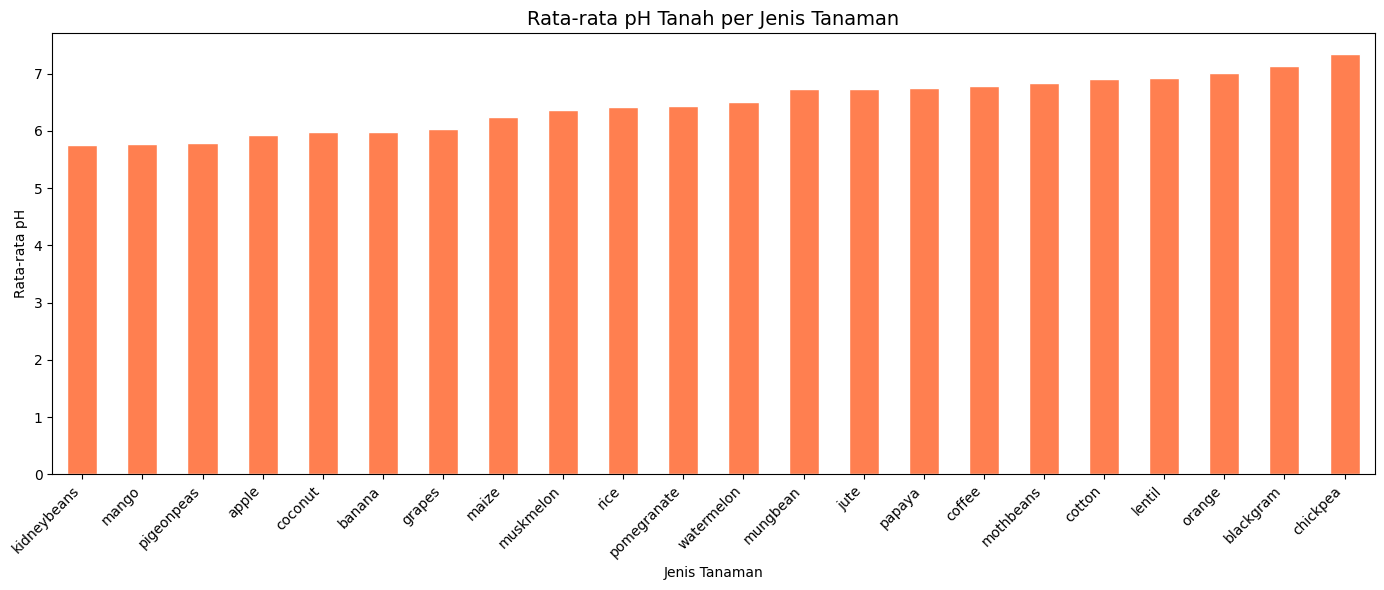

In [45]:
plt.figure(figsize=(14, 6))
df.groupby('label')['ph'].mean().sort_values().plot(
    kind='bar', color='coral', edgecolor='white'
)
plt.title('Rata-rata pH Tanah per Jenis Tanaman', fontsize=14)
plt.xlabel('Jenis Tanaman')
plt.ylabel('Rata-rata pH')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [46]:
df_clean = df.copy()

print("Sebelum:")
print(df_clean.isnull().sum())

#emngisi missing values numerik dengan median
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Kolom '{col}' diisi dengan median: {median_val:.2f}")

#mengisi missing values kategorikal dengan modus
if df_clean['label'].isnull().sum() > 0:
    modus_val = df_clean['label'].mode()[0]
    df_clean['label'].fillna(modus_val, inplace=True)

print("\n Sesudah:")
print(df_clean.isnull().sum())
print("Total missing values:", df_clean.isnull().sum().sum())

Sebelum:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

 Sesudah:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Total missing values: 0


In [47]:
print(f"Jumlah baris sebelum hapus duplikat: {df_clean.shape[0]}")
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f"Jumlah baris setelah hapus duplikat : {df_clean.shape[0]}")

Jumlah baris sebelum hapus duplikat: 2200
Jumlah baris setelah hapus duplikat : 2200


In [48]:
print("Deteksi Outlier")

iso_forest = IsolationForest(contamination=0.02, random_state=42)
outlier_labels = iso_forest.fit_predict(df_clean[numerical_cols])

n_outlier = (outlier_labels == -1).sum()
print(f"Jumlah outlier terdeteksi: {n_outlier}")

df_clean = df_clean[outlier_labels == 1].copy()
df_clean.reset_index(drop=True, inplace=True)
print(f"Jumlah baris setelah hapus outlier: {df_clean.shape[0]}")

Deteksi Outlier
Jumlah outlier terdeteksi: 44
Jumlah baris setelah hapus outlier: 2156


In [49]:
le = LabelEncoder()
df_clean['label_encoded'] = le.fit_transform(df_clean['label'])

print("Label Encoding")
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for crop, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"  {crop:20s} -> {code}")

Label Encoding
  apple                -> 0
  banana               -> 1
  blackgram            -> 2
  chickpea             -> 3
  coconut              -> 4
  coffee               -> 5
  cotton               -> 6
  grapes               -> 7
  jute                 -> 8
  kidneybeans          -> 9
  lentil               -> 10
  maize                -> 11
  mango                -> 12
  mothbeans            -> 13
  mungbean             -> 14
  muskmelon            -> 15
  orange               -> 16
  papaya               -> 17
  pigeonpeas           -> 18
  pomegranate          -> 19
  rice                 -> 20
  watermelon           -> 21


In [50]:
scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])

print("Sebelum Normalisasi:")
print(df_clean[numerical_cols].describe().loc[['min', 'max']])

print("\nSetelah Normalisasi:")
print(df_scaled[numerical_cols].describe().loc[['min', 'max']])


Sebelum Normalisasi:
         N      P      K  temperature   humidity        ph    rainfall
min    0.0    5.0    5.0    10.010813  14.258040  3.504752   20.211267
max  140.0  145.0  205.0    43.675493  99.981876  9.935091  298.560117

Setelah Normalisasi:
       N    P    K  temperature  humidity   ph  rainfall
min  0.0  0.0  0.0          0.0       0.0  0.0       0.0
max  1.0  1.0  1.0          1.0       1.0  1.0       1.0


In [51]:
output_dir = 'crop_recommendation_preprocessing'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'crop_recommendation_processed.csv')
df_scaled.to_csv(output_path, index=False)

print(f"Shape akhir: {df_scaled.shape}")
df_scaled.head()

Shape akhir: (2156, 9)


,N,P,K,temperature,humidity,ph,rainfall,label,label_encoded
0,0.642857,0.264286,0.190,0.322859,0.790267,0.466264,0.656458,rice,20
1,0.607143,0.378571,0.180,0.349317,0.770633,0.549480,0.741675,rice,20
2,0.428571,0.357143,0.195,0.385973,0.793977,0.674219,0.875710,rice,20
3,0.528571,0.214286,0.175,0.489542,0.768751,0.540508,0.799905,rice,20
4,0.557143,0.264286,0.185,0.300593,0.785626,0.641291,0.871231,rice,20
